In [1]:
import numpy as np
import xarray as xr
import os

from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
# plt.ion()

from scipy.stats import linregress
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline

# In this code, we do reconstructions of AMOC based on SST using simple linear regression (within one model)
and test how different the results would be if we take different sections of time series during pre-industrial control run

In [2]:
PATH = '/glade/campaign/cgd/oce/people/rita/CMIP6/'

models_to_process = ['MPI-ESM1-2-HR']
ens_members_appendices  = [ 'r1i1p1f1']

basin_names = [1]

In [3]:
var_name_amoc = 'msftmz'
var_name_sst = 'tos'

scenario = 'piControl'

lat_amoc = 26
color_amoc = 'r'

year_start = 1 # looking at the first 250 years of the control run; could be changed later
year_fin = 250

ntime = 250

period = 20 # yr running mean  

PATH_plots = PATH + 'Plots/'

# Plot AMOC time series

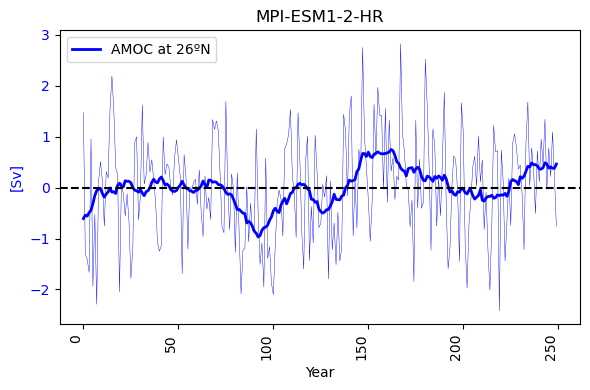

In [4]:
var_name = var_name_amoc

model = models_to_process[0]

filename_amoc = PATH + var_name + '_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[0] + '_all.nc'

amoc = xr.Dataset()

fig, axes = plt.subplots(len(models_to_process), 1, figsize=(6, 4 * len(models_to_process)), sharex=True)
axes = [axes]  

ds = xr.open_dataset(filename_amoc, decode_times=False) 

amoc_time_series = ds[var_name].isel(basin=basin_names[0]).sel(lat=lat_amoc, method='nearest').sel(lev=slice(500, 4000)).max('lev').load()
amoc_time_series = amoc_time_series.coarsen(time=12, boundary="trim").mean().isel(time=slice(0, ntime)) / 1e6 / 1025

# amoc_time_series['time'] = np.arange(year_start-1, year_fin)

amoc_mean = amoc_time_series.mean('time')
amoc_smoothed = (amoc_time_series - amoc_mean).rolling(time=period, center=True, min_periods=1).mean()

amoc_smoothed['time'] = xr.DataArray(np.arange(1, len(amoc_smoothed['time'].values) + 1), dims='time')
amoc_time_series['time'] = xr.DataArray(np.arange(1, len(amoc_time_series['time'].values) + 1), dims='time')
amoc[model] = amoc_smoothed

ax1 = axes[0]
ax1.plot(amoc_smoothed, 'b-', label='AMOC at 26ºN', linewidth=2)
ax1.plot((amoc_time_series - amoc_mean), 'b-', linewidth=0.3)
ax1.set_ylabel('[Sv]', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.axhline(y=0, color='k', linestyle='--')
ax1.legend()
ax1.set_title(f"{model}")
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')

plt.xlabel('Year')
fig.tight_layout()
plt.show()


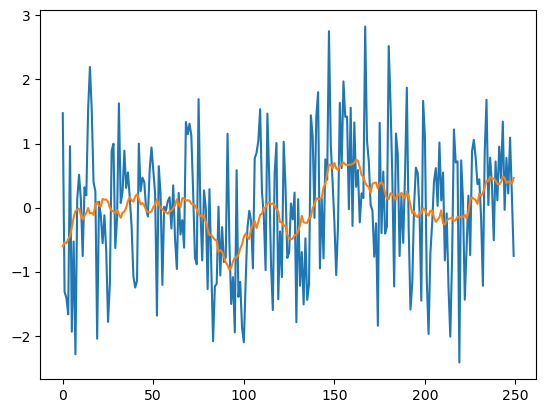

In [5]:
plt.plot(amoc_time_series - amoc_mean)
plt.plot(amoc_smoothed)
plt.show()

# Plot mean SST

/glade/u/home/mmarkina/.conda/envs/cforce/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


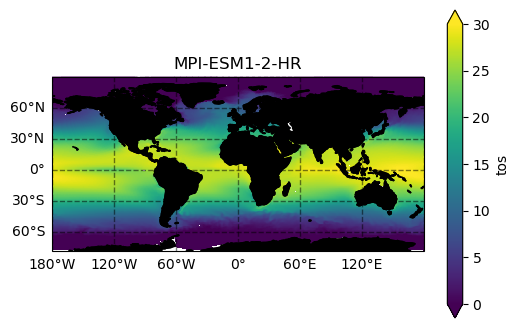

In [6]:
var_name = var_name_sst

fig, axes = plt.subplots(1, 1, figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree()}) #, gridspec_kw=gridspec)
axes = [axes] 

sst = xr.Dataset()


filename_sst = PATH +  var_name + '_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[0] + '_all.nc'

sst_time_series = xr.open_dataset(filename_sst, decode_times = False)[var_name].load().coarsen(time=12, boundary="trim").mean().isel(time = slice(0, ntime))
sst_time_series['time'] = xr.DataArray(np.arange(1, len(sst_time_series['time'].values)+1), dims = 'time')

sst_mean = sst_time_series.mean('time')
sst_smoothed = (sst_time_series - sst_mean).rolling(time=period, center=True).mean()


sst[model] = sst_smoothed

if model == 'CESM2-WACCM':
    im=sst_mean.plot.pcolormesh(ax=axes[0],  transform=ccrs.PlateCarree(), x='lon', y='lat', extend = 'both', cmap='viridis', vmin = 0, vmax = 30, add_colorbar=True, shading='auto')  
else:
    im=sst_mean.plot.pcolormesh(ax=axes[0],  transform=ccrs.PlateCarree(), x='longitude', y='latitude', extend = 'both', cmap='viridis', vmin = 0, vmax = 30, add_colorbar=True, shading='auto')  

axes[0].set_title(f"{model}")
axes[0].coastlines()

land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                    edgecolor='face',
                                    facecolor='black')
axes[0].add_feature(land)

gl = axes[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
        
plt.show(im)
# plt.xlabel('year')
fig.tight_layout()
# plt.savefig(f"{PATH_plots}AHT_OHT_{lat_min}_{lat_max}N_AMOC_{lat_amoc}N_time_series_{scenario}.png")
# plt.show()

# Estimate AMOC timeseries from SST

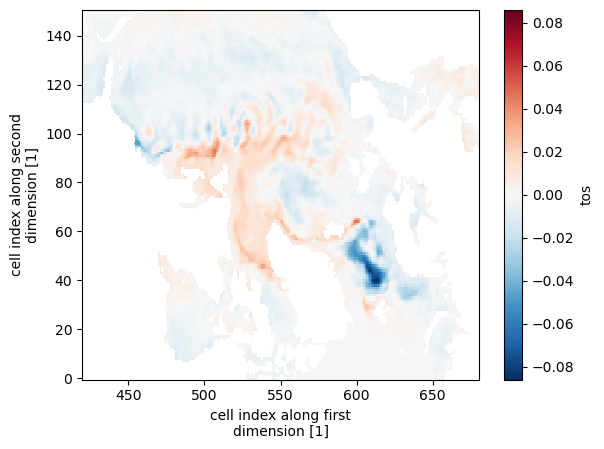

In [7]:
imin = 420
imax = 680

jmin = 0
jmax = 150

sst_smoothed.mean('time').sel(j = slice(jmin, jmax), i = slice(imin, imax)).plot()
plt.show()

nj = 151
ni = 261
ntime = 250


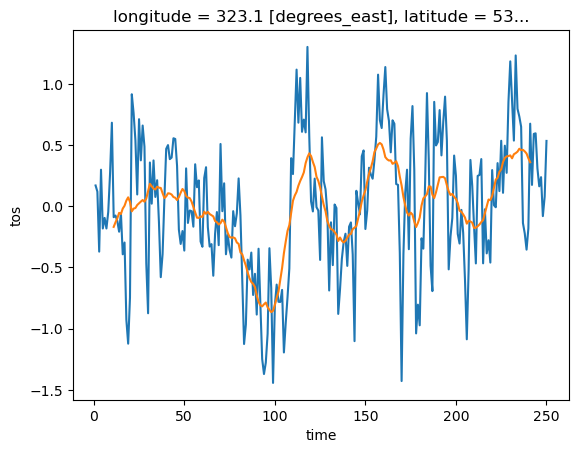

In [8]:
# Sanity check  (SST)

print('nj = ' + str(sst_time_series.mean('time').sel(j = slice(jmin, jmax), i = slice(imin, imax)).shape[0]))
print('ni = ' + str(sst_time_series.mean('time').sel(j = slice(jmin, jmax), i = slice(imin, imax)).shape[1]))
print('ntime = ' + str(sst_time_series.shape[0]))


(sst_time_series - sst_mean).sel(j=80, i = 550).plot()
sst_smoothed.sel(j=80, i = 550).plot()
plt.show()

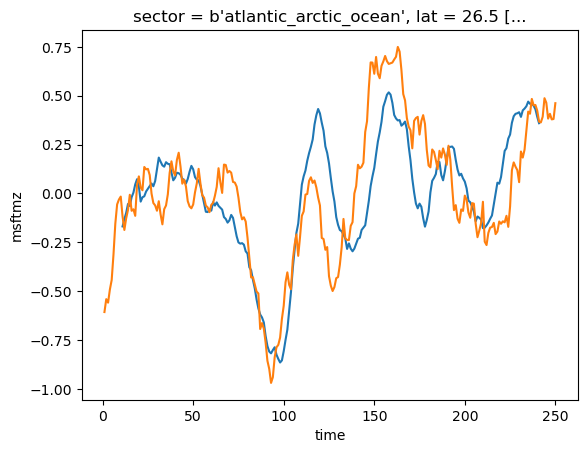

In [9]:
# Sanity check - time series (SST and AMOC) that I'm going to use for reconstructions

(sst_smoothed).sel(j=80, i = 550).plot()
(amoc_smoothed).plot()
plt.show()

# Compute regressions and reconstruct AMOC from SST for 2 separate time periods

In [10]:
coords = {
    'latitude': (('j', 'i'), sst.latitude.sel(j = slice(jmin, jmax), i = slice(imin, imax)).values),
    'longitude': (('j', 'i'), sst.longitude.sel(j = slice(jmin, jmax), i = slice(imin, imax)).values),
    'i': sst.i.sel(i = slice(imin, imax)).values,
    'j': sst.j.sel(j = slice(jmin, jmax)).values
}

In [11]:
def prepare_and_normalize_sst(sst, time_start, time_end, jmin, jmax, imin, imax):
    """
    Prepare SST by subsetting to North Atlantic, filling NaNs, stacking spatial points, and normalizing.
    """
    sst_selected = sst.isel(time=slice(time_start, time_end)) \
            .sel(j=slice(jmin, jmax), i=slice(imin, imax)) \
            .fillna(0).stack(spatial=("j", "i")).values

    # Normalize SST per spatial point
    sst_mean = np.mean(sst_selected, axis=0)
    sst_std = np.std(sst_selected, axis=0)
    sst_std[sst_std == 0] = 1  # Avoid division by zero
    return (sst_selected - sst_mean) / sst_std

def prepare_and_normalize_amoc(amoc, time_start, time_end):
    """
    Prepare AMOC by subsetting, filling NaNs, and normalizing.
    """
    amoc_selected = amoc.isel(time=slice(time_start, time_end)).fillna(0).values
    amoc_mean = np.mean(amoc_selected)
    amoc_std = np.std(amoc_selected)
    return amoc_selected, (amoc_selected - amoc_mean) / amoc_std, amoc_mean, amoc_std

def train_regression_and_reconstruct(sst_normalized, amoc, amoc_std):
    """
    Train regression (compute f) and reconstruct AMOC using SST.
    """
    f = sst_normalized.T @ amoc / sst_normalized.shape[0]
    amoc_reconstructed = sst_normalized @ f
    amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed)  # Rescale
    return f, amoc_reconstructed

def plot_regression_coefficients(f, ny, nx, title):
    """
    Reshape and plot regression coefficients with land masked as NaN.
    """
    fr = np.reshape(f, [ny, nx])
    fr_masked = np.where(fr == 0, np.nan, fr)
    plt.figure(figsize=(8, 6))
    plt.contourf(np.flipud(fr_masked), cmap="viridis", levels=20)
    plt.colorbar(label="Regression Coefficients")
    plt.title(title)
    plt.show()

def plot_amoc_comparison(amoc_original, amoc_reconstructed, time_start, time_end, title):
    """
    Plot original vs reconstructed AMOC.
    """
    years = np.arange(time_start, time_end)
    amoc_original_da = xr.DataArray(amoc_original, dims='year', coords={'year': years})
    amoc_reconstructed_da = xr.DataArray(amoc_reconstructed, dims='year', coords={'year': years})
    
    plt.figure(figsize=(8, 5))
    amoc_original_da.plot(label="Original AMOC", linewidth=2)
    amoc_reconstructed_da.plot(label="Reconstructed AMOC", linestyle="--", linewidth=2)
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("AMOC [Sv]")
    plt.legend()
    plt.show()

Processing time period 1: 50-150


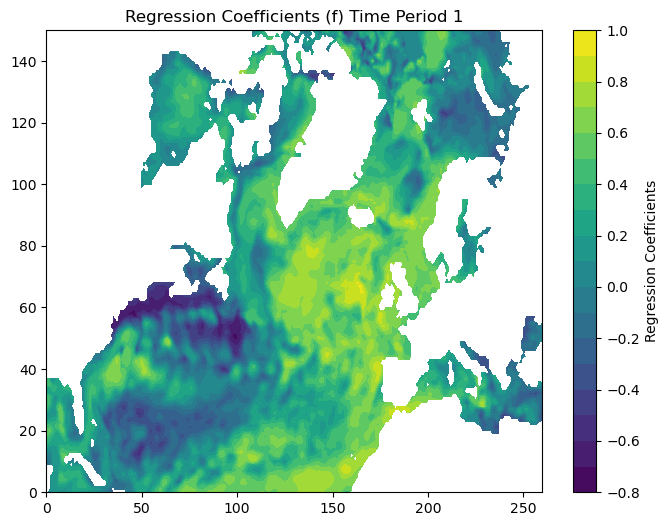

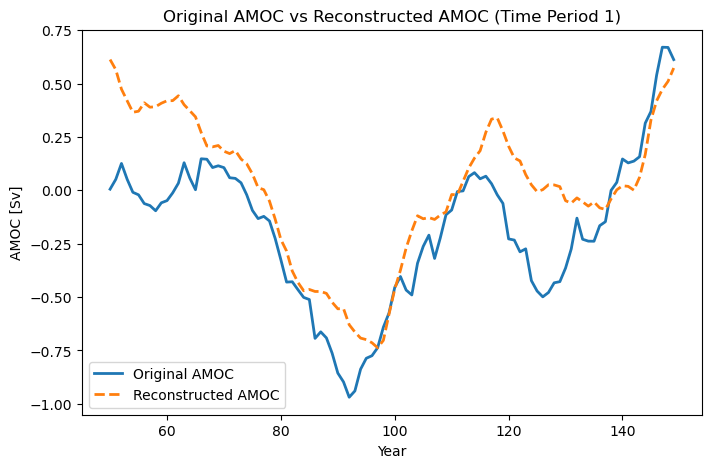

f range: -0.7842 to 0.9244
AMOC range: -0.9693 to 0.6702
Reconstructed AMOC range: -0.7376 to 0.6125
Processing time period 2: 100-200


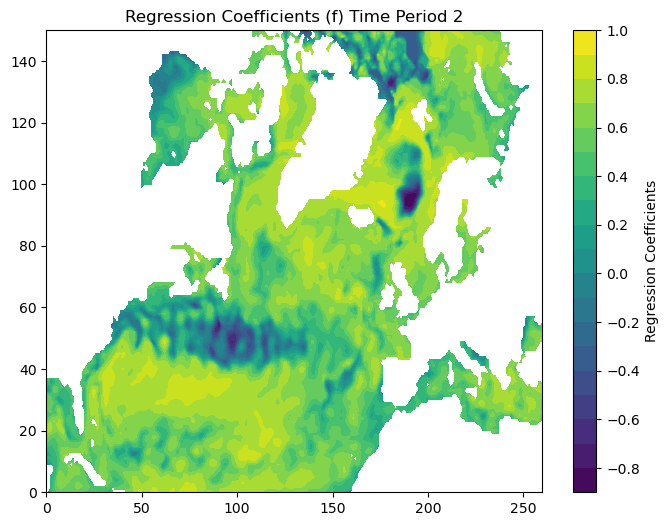

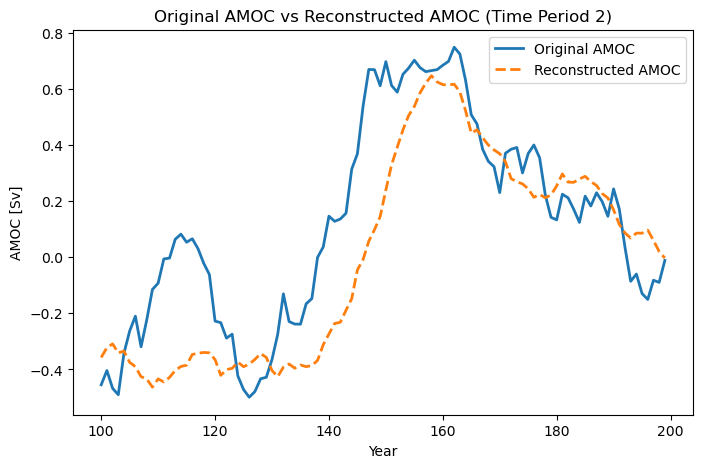

f range: -0.8945 to 0.9196
AMOC range: -0.4991 to 0.7495
Reconstructed AMOC range: -0.4631 to 0.6478


In [12]:
imin = 420
imax = 680

jmin = 0
jmax = 150


# Define time intervals and North Atlantic spatial boundaries
time_periods = [(50, 150), (100, 200)]  

# Get spatial grid dimensions for the North Atlantic region
ny = sst_smoothed.mean('time').sel(j = slice(jmin, jmax), i = slice(imin, imax)).shape[0]
nx = sst_smoothed.mean('time').sel(j = slice(jmin, jmax), i = slice(imin, imax)).shape[1]

# Loop over time periods and process data
for i, (time_start, time_end) in enumerate(time_periods):
    print(f"Processing time period {i+1}: {time_start}-{time_end}")

    # Prepare and normalize data    
    sst_normalized = prepare_and_normalize_sst(sst_smoothed, time_start, time_end, jmin, jmax, imin, imax)
    amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc_smoothed, time_start, time_end)

    # Train regression and reconstruct AMOC
    f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

    # Plot regression coefficients
    plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) Time Period {i+1}")

    # Plot AMOC comparison
    plot_amoc_comparison(amoc, amoc_reconstructed, time_start, time_end, 
                         f"Original AMOC vs Reconstructed AMOC (Time Period {i+1})")

    # Debugging information
    print(f"f range: {np.min(f):.4f} to {np.max(f):.4f}")
    print(f"AMOC range: {np.min(amoc):.4f} to {np.max(amoc):.4f}")
    print(f"Reconstructed AMOC range: {np.min(amoc_reconstructed):.4f} to {np.max(amoc_reconstructed):.4f}")


# Plot reconstructions for the first 100 years based on regressions computed for different periods

Processing time period 1: 20-120


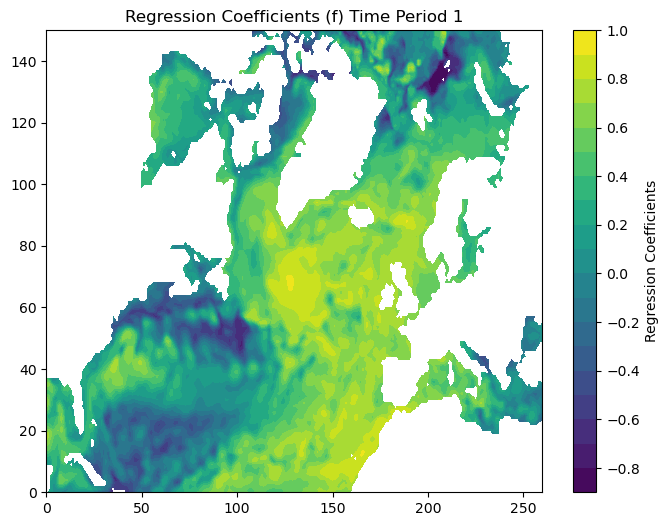

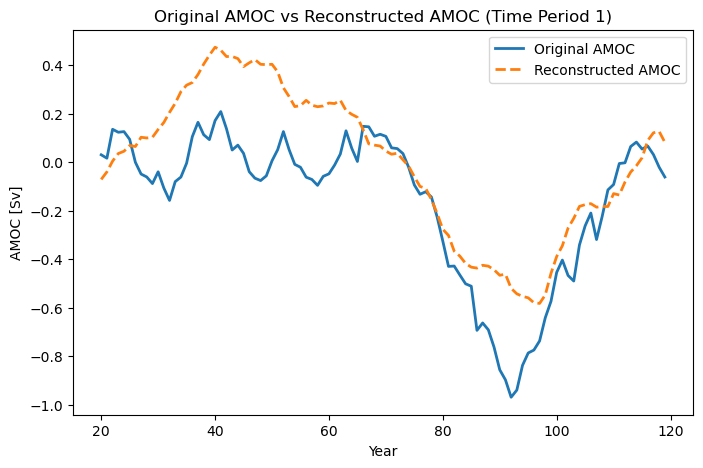

f range: -0.8604 to 0.9185
AMOC range: -0.9693 to 0.2083
Reconstructed AMOC range: -0.5825 to 0.4737
Processing time period 2: 40-140


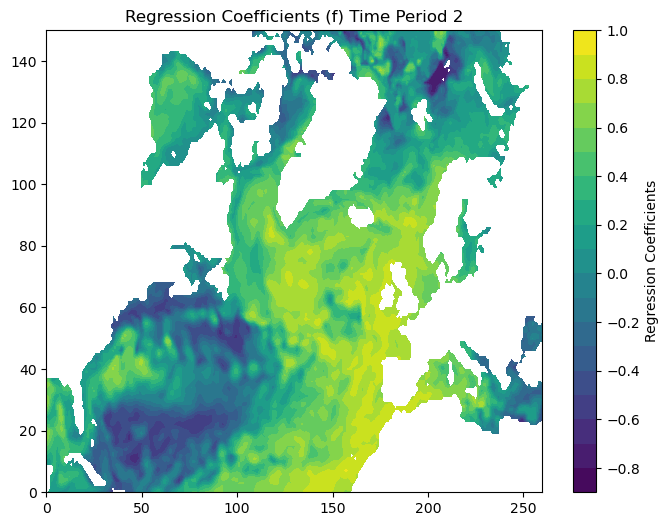

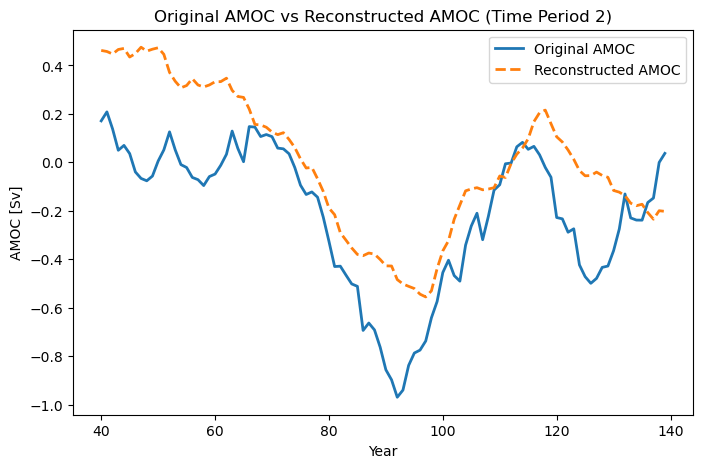

f range: -0.8189 to 0.9082
AMOC range: -0.9693 to 0.2083
Reconstructed AMOC range: -0.5553 to 0.4752
Processing time period 3: 60-160


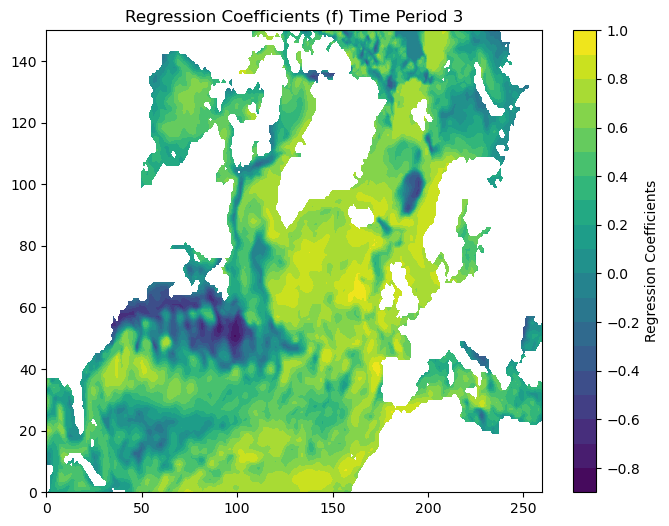

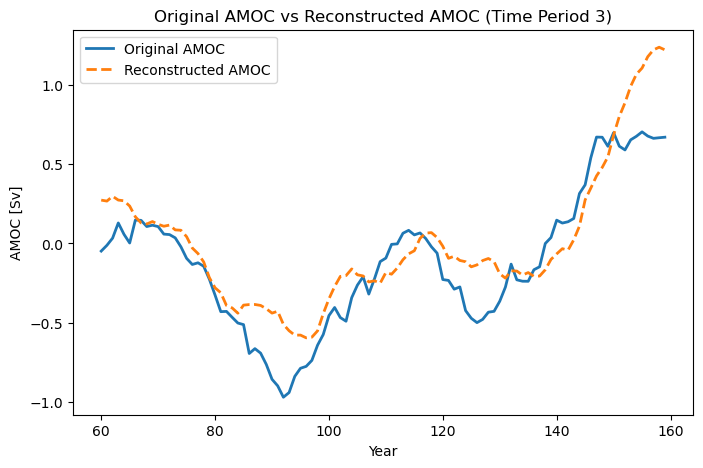

f range: -0.8218 to 0.9540
AMOC range: -0.9693 to 0.7032
Reconstructed AMOC range: -0.5949 to 1.2366
Processing time period 4: 80-180


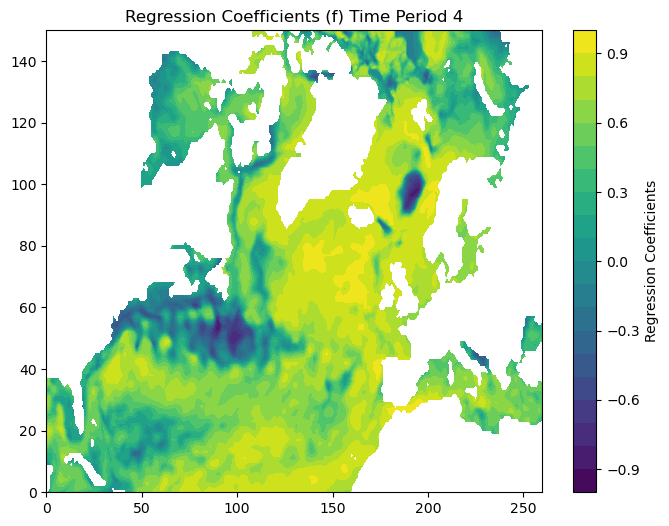

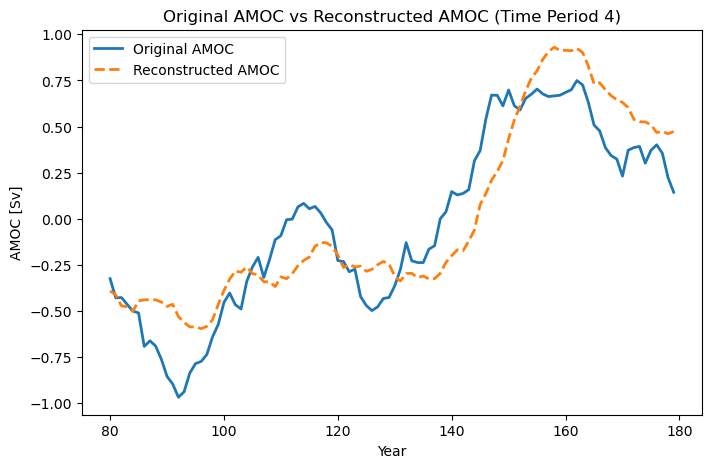

f range: -0.9029 to 0.9660
AMOC range: -0.9693 to 0.7495
Reconstructed AMOC range: -0.5969 to 0.9303
Processing time period 5: 100-200


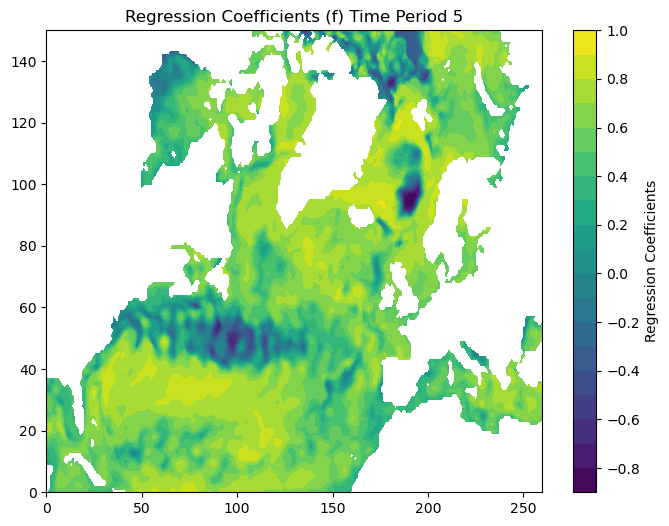

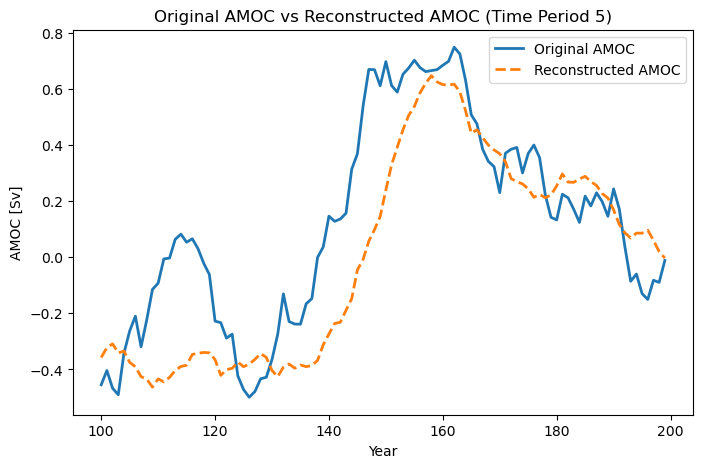

f range: -0.8945 to 0.9196
AMOC range: -0.4991 to 0.7495
Reconstructed AMOC range: -0.4631 to 0.6478
Processing time period 6: 120-220


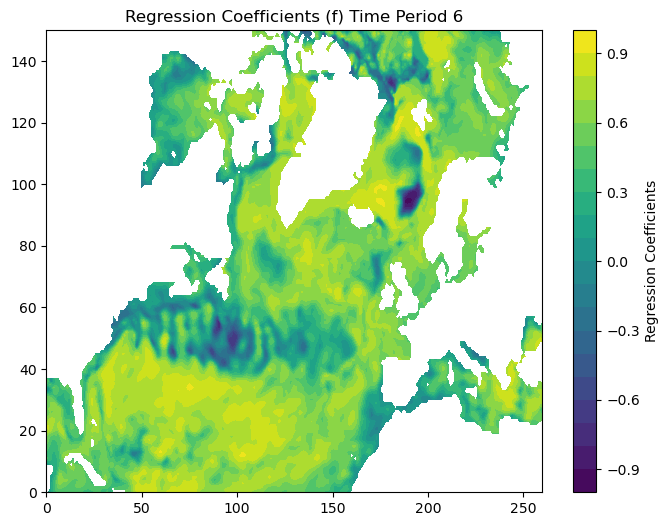

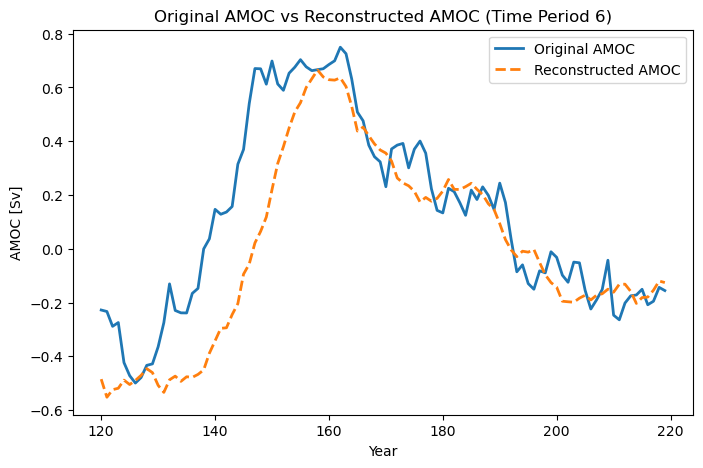

f range: -0.9414 to 0.9315
AMOC range: -0.4991 to 0.7495
Reconstructed AMOC range: -0.5519 to 0.6647
Processing time period 7: 140-240


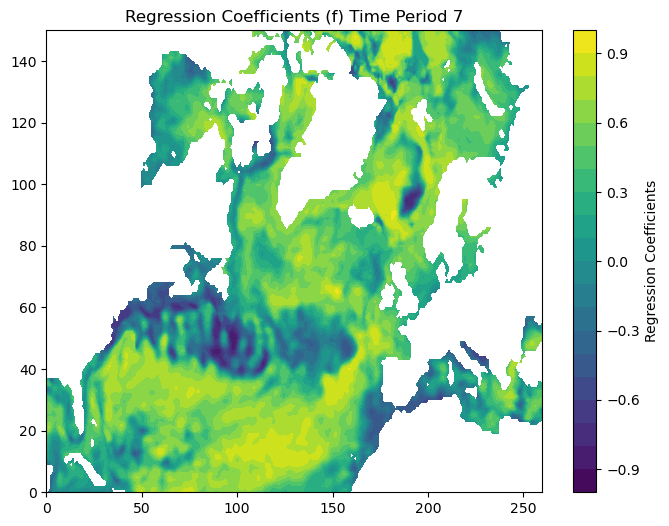

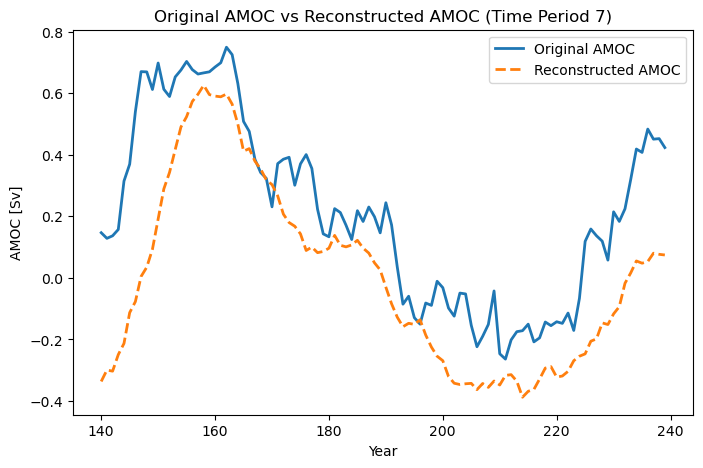

f range: -0.9012 to 0.9282
AMOC range: -0.2640 to 0.7495
Reconstructed AMOC range: -0.3879 to 0.6260


In [13]:
imin = 420
imax = 680

jmin = 0
jmax = 150


# Define time intervals and North Atlantic spatial boundaries
# time_periods = [(0, 100), (20, 120), (40, 140), (60, 160), (80, 180), (100, 200), (120, 220), (140, 240)]  
time_periods = [(20, 120), (40, 140), (60, 160), (80, 180), (100, 200), (120, 220), (140, 240)]  


# Get spatial grid dimensions for the North Atlantic region
ny = sst_smoothed.mean('time').sel(j = slice(jmin, jmax), i = slice(imin, imax)).shape[0]
nx = sst_smoothed.mean('time').sel(j = slice(jmin, jmax), i = slice(imin, imax)).shape[1]

# Loop over time periods and process data
for i, (time_start, time_end) in enumerate(time_periods):
    print(f"Processing time period {i+1}: {time_start}-{time_end}")

    # Prepare and normalize data    
    sst_normalized = prepare_and_normalize_sst(sst_smoothed, time_start, time_end, jmin, jmax, imin, imax)
    amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc_smoothed, time_start, time_end)

    # Train regression and reconstruct AMOC
    f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

    # Plot regression coefficients
    plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) Time Period {i+1}")

    # Plot AMOC comparison
    plot_amoc_comparison(amoc, amoc_reconstructed, time_start, time_end, 
                         f"Original AMOC vs Reconstructed AMOC (Time Period {i+1})")

    # Debugging information
    print(f"f range: {np.min(f):.4f} to {np.max(f):.4f}")
    print(f"AMOC range: {np.min(amoc):.4f} to {np.max(amoc):.4f}")
    print(f"Reconstructed AMOC range: {np.min(amoc_reconstructed):.4f} to {np.max(amoc_reconstructed):.4f}")


Processing time period 1: 20-120
f range: -0.8604 to 0.9185
Processing time period 2: 40-140
f range: -0.8189 to 0.9082
Processing time period 3: 60-160
f range: -0.8218 to 0.9540
Processing time period 4: 80-180
f range: -0.9029 to 0.9660
Processing time period 5: 100-200
f range: -0.8945 to 0.9196
Processing time period 6: 120-220
f range: -0.9414 to 0.9315
Processing time period 7: 140-240
f range: -0.9012 to 0.9282


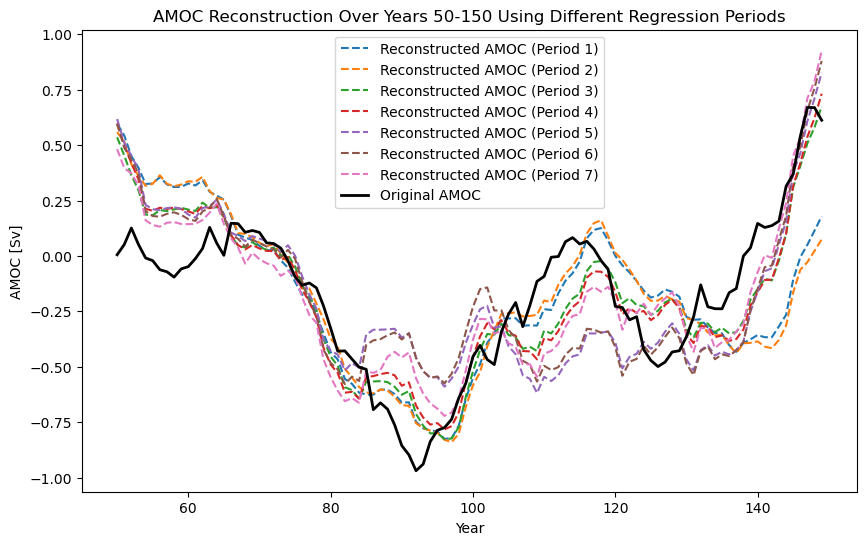

In [14]:
# ===== Main Code =====

# Spatial domain for North Atlantic
imin, imax = 420, 680
jmin, jmax = 0, 150

# Define time periods for regression
# time_periods = [(0, 100), (20, 120), (40, 140), (60, 160), (80, 180), (100, 200), (120, 220), (140, 240)]
time_periods = [(20, 120), (40, 140), (60, 160), (80, 180), (100, 200), (120, 220), (140, 240)]

# Reconstruction period: First 100 years
reconstruction_period = (50, 150)

# Prepare SST and AMOC for reconstruction period (used for all regressions)
sst_recon_normalized = prepare_and_normalize_sst(sst_smoothed, reconstruction_period[0], reconstruction_period[1], jmin, jmax, imin, imax)
amoc_recon, _, amoc_recon_mean, amoc_recon_std = prepare_and_normalize_amoc(amoc_smoothed, reconstruction_period[0], reconstruction_period[1])

# Storage for all reconstructions
amoc_reconstructions = []

# Grid dimensions for plotting regression coefficients
ny = sst_smoothed.mean('time').sel(j=slice(jmin, jmax), i=slice(imin, imax)).shape[0]
nx = sst_smoothed.mean('time').sel(j=slice(jmin, jmax), i=slice(imin, imax)).shape[1]

# Loop over each time period
for i, (time_start, time_end) in enumerate(time_periods):
    print(f"Processing time period {i+1}: {time_start}-{time_end}")

    # Step 1: Prepare SST and AMOC for the current time period
    sst_normalized = prepare_and_normalize_sst(sst_smoothed, time_start, time_end, jmin, jmax, imin, imax)
    _, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc_smoothed, time_start, time_end)

    # Step 2: Train regression and compute regression coefficients
    f, _ = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

    # Step 3: Reconstruct AMOC for the first 100 years
    amoc_reconstructed = sst_recon_normalized @ f
    amoc_reconstructed = amoc_reconstructed * amoc_recon_std / np.std(amoc_reconstructed) + amoc_recon_mean
    amoc_reconstructions.append(amoc_reconstructed)

    # # Step 4: Plot regression coefficients (optional)
    # plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) Time Period {i+1}")

    # Debugging output
    print(f"f range: {np.min(f):.4f} to {np.max(f):.4f}")

# ===== Plot AMOC Reconstructions =====

years = np.arange(reconstruction_period[0], reconstruction_period[1])

plt.figure(figsize=(10, 6))

# Plot all reconstructed AMOCs
for i, amoc_reconstructed in enumerate(amoc_reconstructions):
    plt.plot(years, amoc_reconstructed, linestyle='--', label=f"Reconstructed AMOC (Period {i+1})")

# Plot original AMOC
plt.plot(years, amoc_recon, color='k', linewidth=2, label="Original AMOC")

# Plot formatting
plt.title("AMOC Reconstruction Over Years 50-150 Using Different Regression Periods")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.legend()
plt.show()
